In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Resolve the raw data folder relative to the notebook, not with an absolute path
# Why: keeps the project portable (works on any machine / when cloned from git)
RAW_DIR = Path.cwd().parent / "data" / "raw"

# We inspect a single turbine first (WT01). We will generalize to all turbines later
sample_file = RAW_DIR / "Turbine_Data_Penmanshiel_01_2020-01-01_-_2021-01-01_1042.csv"

assert sample_file.exists(), f"File not found: {sample_file}"
print(f"Reading: {sample_file.name}")

Reading: Turbine_Data_Penmanshiel_01_2020-01-01_-_2021-01-01_1042.csv


In [2]:
# Read ONLY the first 1000 rows to inspect structure without loading the full file.
# skiprows=9 : skip the 9 metadata comment lines; row 10 becomes the header
# The header's first column arrives as '# Date and time' because of the '# ' prefix,
df = pd.read_csv(sample_file, skiprows=9, nrows=1000)

# Clean the leading '# ' that Greenbyte leaves on the first column name
df.columns = df.columns.str.replace(r"^#\s*", "", regex=True)

print(f"Shape (rows, columns): {df.shape}")
df.head()

Shape (rows, columns): (1000, 300)


,Date and time,Wind speed (m/s),"Wind speed, Standard deviation (m/s)","Wind speed, Minimum (m/s)","Wind speed, Maximum (m/s)",Long Term Wind (m/s),Wind speed Sensor 1 (m/s),"Wind speed Sensor 1, Standard deviation (m/s)","Wind speed Sensor 1, Minimum (m/s)","Wind speed Sensor 1, Maximum (m/s)",...,Tower Acceleration y (mm/ss),"Tower Acceleration X, Min (mm/ss)","Tower Acceleration X, Max (mm/ss)","Tower Acceleration Y, Min (mm/ss)","Tower Acceleration Y, Max (mm/ss)","Drive train acceleration, Max (mm/ss)","Drive train acceleration, Min (mm/ss)","Drive train acceleration, StdDev (mm/ss)","Tower Acceleration X, StdDev (mm/ss)","Tower Acceleration Y, StdDev (mm/ss)"
0,2020-01-01 00:00:00,2.627427,0.750119,1.251000,4.254200,8.7,2.722359,0.759100,1.151028,3.817483,...,7.355085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-01 00:10:00,2.513875,0.500827,1.426500,3.470249,8.7,2.361884,0.468112,1.515199,3.392465,...,3.305833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-01 00:20:00,1.909575,0.309158,1.151625,2.400000,8.7,1.774933,0.250598,1.167147,2.160854,...,3.989333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-01 00:30:00,1.269637,0.371793,0.542625,1.852875,8.7,0.767450,0.758972,0.000000,1.888025,...,4.152441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-01 00:40:00,0.273525,0.194069,0.078000,0.938625,8.7,0.000000,0.000000,0.000000,0.000000,...,4.020226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Confirm the sampling interval is 10 minutes by parsing the timestamp column
df["Date and time"] = pd.to_datetime(df["Date and time"])
deltas = df["Date and time"].diff().value_counts()
print("Time between consecutive readings (top values):")
print(deltas.head())

Time between consecutive readings (top values):
Date and time
0 days 00:10:00    999
Name: count, dtype: int64


In [4]:
# List all column names so we can see the avg/min/max/std variants per signal
print(f"Total columns: {len(df.columns)}\n")
for col in df.columns:
    print(col)

Total columns: 300

Date and time
Wind speed (m/s)
Wind speed, Standard deviation (m/s)
Wind speed, Minimum (m/s)
Wind speed, Maximum (m/s)
Long Term Wind (m/s)
Wind speed Sensor 1 (m/s)
Wind speed Sensor 1, Standard deviation (m/s)
Wind speed Sensor 1, Minimum (m/s)
Wind speed Sensor 1, Maximum (m/s)
Wind speed Sensor 2 (m/s)
Wind speed Sensor 2, Standard deviation (m/s)
Wind speed Sensor 2, Minimum (m/s)
Wind speed Sensor 2, Maximum (m/s)
Density adjusted wind speed (m/s)
Wind direction (°)
Nacelle position (°)
Wind direction, Standard deviation (°)
Wind direction, Minimum (°)
Wind direction, Maximum (°)
Nacelle position, Standard deviation (°)
Nacelle position, Minimum (°)
Nacelle position, Maximum (°)
Vane position 1+2 (°)
Vane position 1+2, Max (°)
Vane position 1+2, Min (°)
Vane position 1+2, StdDev (°)
Energy Export (kWh)
Energy Export counter (kWh)
Energy Import (kWh)
Energy Import counter (kWh)
Lost Production (Contractual) (kWh)
Lost Production (Time-based IEC B.2.2) (kWh)
Lo

In [5]:
signals = pd.read_excel("../data/raw/Penmanshiel_WT_dataSignalMapping.xlsx")
print(f"Shape: {(signals.shape)}")
signals.head()

Shape: (78, 6)


,DataSignalId,TitleGreenbyte,TitleManufacturer,Unit,MinValue,MaxValue
0,1,Wind speed,Wind speed,m/s,-10,80
1,2,Wind direction,Wind direction,°,0,360
2,3,Nacelle position,Nacelle orientation,°,0,360
3,4,Energy Export,Entire active energy generation,kWh,-1000,\t
4,5,Power,Actual value of active power,kW,-1000,10000


In [6]:
# Search of the useful variables

signals[signals["TitleGreenbyte"].str.contains("temp",case=False,na=False)]

,DataSignalId,TitleGreenbyte,TitleManufacturer,Unit,MinValue,MaxValue
7,9,Front bearing temperature,Axle bearing temperature 1,°C,-275,200
8,10,Rear bearing temperature,Axle bearing temperature 2,°C,-275,200
9,22,Stator temperature 1,Temperature for generator stator,°C,-275,200
10,24,Nacelle ambient temperature,Outdoor temp. nacelle,°C,-275,200
11,25,Nacelle temperature,Inside temperature nacelle,°C,-275,200
12,34,Transformer temperature,Temp. transf.,°C,-275,200
28,117,Gear oil inlet temperature,Temp. gearb. inlet 1s,°C,-275,200
29,118,Generator bearing rear temperature,Temperature of bearing 2,°C,-275,200
30,119,Generator bearing front temperature,Temperature of bearing 1,°C,-275,200
31,178,Gear oil temperature,Gear oil temperature,°C,-275,200


In [7]:
signals[signals["TitleGreenbyte"].str.contains("power",case=False,na=False)]

,DataSignalId,TitleGreenbyte,TitleManufacturer,Unit,MinValue,MaxValue
4,5,Power,Actual value of active power,kW,-1000,10000
5,6,Power factor (cosphi),Power factor,NaN,-1,1
6,7,Reactive power,Actual value of reactive power,kvar,-1000,10000
37,323,Apparent power,Actual value of apparent power,kVA,-1000,10000
59,1702,Turbine Power setpoint,Actual P setpoint,kW,-1000,10000
66,558,GMS Power,1 second average of the active power,kW,-1000,10000
67,559,GMS Reactive power,1 second average of the reactive power,kvar,-1000,10000
73,798,GMS Apparent Power,1 second average of the apparent power,kVA,-1000,10000
76,840,GMS Power Setpoint,Power setpoint,kW,-1000,10000


In [8]:
signals[signals["TitleGreenbyte"].str.contains("wind",case=False,na=False)]

,DataSignalId,TitleGreenbyte,TitleManufacturer,Unit,MinValue,MaxValue
0,1,Wind speed,Wind speed,m/s,-10,80
1,2,Wind direction,Wind direction,°,0,360
45,450,Cable windings from calibration point,Cable winding: number of windings from calibra...,NaN,\t,\t
51,1475,Wind speed Sensor 1,Wind speed 1 1s,m/s,-10,80
52,1479,Wind speed Sensor 2,Wind speed 2 1s,m/s,-10,80


In [9]:
signals[signals["TitleGreenbyte"].str.contains("pitch",case=False,na=False)]

,DataSignalId,TitleGreenbyte,TitleManufacturer,Unit,MinValue,MaxValue
20,80,Blade angle (pitch position) A,Pitch angle for blade 1,°,-5,360
21,81,Blade angle (pitch position) B,Pitch angle for blade 2,°,-5,360
22,82,Blade angle (pitch position) C,Pitch angle for blade 3,°,-5,360


## Selected signals

We keep a focused subset of the ~78 available signals instead of all 300 CSV columns.

- **Power curve**: `Wind speed` and `Power` (active power), the core relationship
  in turbine performance.
- **Component temperatures**: `Gear oil temperature`, `Generator bearing
  front/rear temperature`, `Front/Rear bearing temperature`. These components
  are common failure points, so their temperature trends are early fault indicators.
- **Nacelle temperature**: kept as ambient context, not a fault indicator itself.
- **Pitch**: `Blade angle (pitch position) A/B/C`. Pitch control affects power
  output directly, so it helps explain power curve deviations that are not anomalies.

Redundant sensors (`Wind speed Sensor 1/2`) and non-output electrical signals
(`Reactive power`, `Apparent power`) are excluded to keep this first pass readable.


In [10]:
# Variables in df

power_cols = [col for col in df.columns if "power" in col.lower()]
print(power_cols)

wind_speed_cols = [col for col in df.columns if "wind speed" in col.lower()]
print(wind_speed_cols)

gear_oil_cols = [col for col in df.columns if "gear oil" in col.lower()]
print(gear_oil_cols)

gen_bearing_front_cols = [col for col in df.columns if "generator bearing front" in col.lower()]
print(gen_bearing_front_cols)

gen_bearing_rear_cols = [col for col in df.columns if "generator bearing rear" in col.lower()]
print(gen_bearing_rear_cols)

front_bearing_cols = [col for col in df.columns if "front bearing" in col.lower()]
print(front_bearing_cols)

rear_bearing_cols = [col for col in df.columns if "rear bearing" in col.lower()]
print(rear_bearing_cols)

nacelle_temp_cols = [col for col in df.columns if "nacelle temperature" in col.lower()]
print(nacelle_temp_cols)

pitch_cols = [col for col in df.columns if "blade angle" in col.lower()]
print(pitch_cols)


['Power (kW)', 'Potential power default PC (kW)', 'Power, Standard deviation (kW)', 'Power, Minimum (kW)', 'Power, Maximum (kW)', 'Potential power learned PC (kW)', 'Potential power reference turbines (kW)', 'Cascading potential power (kW)', 'Cascading potential power for performance (kW)', 'Potential power met mast anemometer (kW)', 'Potential power primary reference turbines (kW)', 'Potential power secondary reference turbines (kW)', 'Turbine Power setpoint (kW)', 'Potential power estimated (kW)', 'Potential power MPC (kW)', 'Potential power met mast anemometer MPC (kW)', 'Turbine Power setpoint, Max (kW)', 'Turbine Power setpoint, Min (kW)', 'Turbine Power setpoint, StdDev (kW)', 'Power factor (cosphi)', 'Power factor (cosphi), Max', 'Power factor (cosphi), Min', 'Power factor (cosphi), Standard deviation', 'Reactive power (kvar)', 'Reactive power, Max (kvar)', 'Reactive power, Min (kvar)', 'Reactive power, Standard deviation (kvar)', 'Apparent power (kVA)', 'Apparent power, Max (kV

In [11]:
# Selection of the key columns

key_cols = [
    "Wind speed (m/s)",
    "Wind speed, Standard deviation (m/s)",
    "Power (kW)",
    "Power, Standard deviation (kW)",
    "Gear oil temperature (°C)",
    "Generator bearing front temperature (°C)",
    "Generator bearing rear temperature (°C)",
    "Front bearing temperature (°C)",
    "Rear bearing temperature (°C)",
    "Nacelle temperature (°C)",
    "Blade angle (pitch position) A (°)",
    "Blade angle (pitch position) B (°)",
    "Blade angle (pitch position) C (°)",
]

# Keep the timestamp too: without it we lose the ability to plot trends over time
df_key=df[["Date and time"] + key_cols]

print(df_key.shape)
df_key.head()


(1000, 14)


,Date and time,Wind speed (m/s),"Wind speed, Standard deviation (m/s)",Power (kW),"Power, Standard deviation (kW)",Gear oil temperature (°C),Generator bearing front temperature (°C),Generator bearing rear temperature (°C),Front bearing temperature (°C),Rear bearing temperature (°C),Nacelle temperature (°C),Blade angle (pitch position) A (°),Blade angle (pitch position) B (°),Blade angle (pitch position) C (°)
0,2020-01-01 00:00:00,2.627427,0.750119,-4.735457,9.274467,53.319999,38.501666,37.513333,57.431667,53.240000,10.503333,26.361820,26.361820,26.367006
1,2020-01-01 00:10:00,2.513875,0.500827,-2.004182,0.558304,52.228333,37.466667,37.066666,53.753333,51.310000,13.165000,44.990002,44.990002,44.990002
2,2020-01-01 00:20:00,1.909575,0.309158,-2.267019,0.462581,51.083333,36.821666,36.583334,51.283334,49.995000,14.381667,44.990002,44.990002,44.990002
3,2020-01-01 00:30:00,1.269637,0.371793,-1.756993,0.190639,50.500000,36.215000,36.201666,49.835000,49.251667,14.678333,44.990002,44.990002,44.990002
4,2020-01-01 00:40:00,0.273525,0.194069,-1.430491,0.309711,50.376667,35.618334,35.911668,48.603333,48.630000,14.655000,44.990002,44.990002,44.990002


In [12]:
# We study all the data, not only the first 1000 rows

raw_key_cols = ["# Date and time"] + key_cols

df_key = pd.read_csv(sample_file, skiprows=9, usecols=raw_key_cols)
df_key.columns = df_key.columns.str.replace(r"^#\s*", "", regex=True)
df_key["Date and time"] = pd.to_datetime(df_key["Date and time"])

print(df_key.shape)
df_key.head()


(52704, 14)


,Date and time,Wind speed (m/s),"Wind speed, Standard deviation (m/s)",Power (kW),"Power, Standard deviation (kW)",Front bearing temperature (°C),Rear bearing temperature (°C),Nacelle temperature (°C),Generator bearing rear temperature (°C),Generator bearing front temperature (°C),Gear oil temperature (°C),Blade angle (pitch position) A (°),Blade angle (pitch position) B (°),Blade angle (pitch position) C (°)
0,2020-01-01 00:00:00,2.627427,0.750119,-4.735457,9.274467,57.431667,53.240000,10.503333,37.513333,38.501666,53.319999,26.361820,26.361820,26.367006
1,2020-01-01 00:10:00,2.513875,0.500827,-2.004182,0.558304,53.753333,51.310000,13.165000,37.066666,37.466667,52.228333,44.990002,44.990002,44.990002
2,2020-01-01 00:20:00,1.909575,0.309158,-2.267019,0.462581,51.283334,49.995000,14.381667,36.583334,36.821666,51.083333,44.990002,44.990002,44.990002
3,2020-01-01 00:30:00,1.269637,0.371793,-1.756993,0.190639,49.835000,49.251667,14.678333,36.201666,36.215000,50.500000,44.990002,44.990002,44.990002
4,2020-01-01 00:40:00,0.273525,0.194069,-1.430491,0.309711,48.603333,48.630000,14.655000,35.911668,35.618334,50.376667,44.990002,44.990002,44.990002


In [13]:
# Cleaning

print((df_key["Wind speed (m/s)"] < -10).sum())
print((df_key["Wind speed (m/s)"] > 80).sum())
print((df_key["Power (kW)"] < -1000).sum())
print((df_key["Power (kW)"] > 10000).sum())
print((df_key["Power (kW)"] < 0).sum())

df_key.isna().sum()


0
0
0
0
7002


Date and time                                  0
Wind speed (m/s)                            3100
Wind speed, Standard deviation (m/s)        3287
Power (kW)                                  3101
Power, Standard deviation (kW)              3289
Front bearing temperature (°C)              3287
Rear bearing temperature (°C)               3287
Nacelle temperature (°C)                    3287
Generator bearing rear temperature (°C)     3100
Generator bearing front temperature (°C)    3100
Gear oil temperature (°C)                   3287
Blade angle (pitch position) A (°)          3288
Blade angle (pitch position) B (°)          3288
Blade angle (pitch position) C (°)          3288
dtype: int64

In [14]:
nan_rows = df_key[df_key["Power (kW)"].isna()]
nan_rows["Date and time"].describe()
nan_rows["Date and time"].dt.date.value_counts().sort_index()


Date and time
2020-01-08      4
2020-02-18      1
2020-02-21     45
2020-04-23      1
2020-06-08     92
2020-06-09    144
2020-06-10    144
2020-06-11     92
2020-07-03     37
2020-07-17     35
2020-07-26     20
2020-08-12      1
2020-08-18      2
2020-08-19      1
2020-08-25      5
2020-09-08      5
2020-09-23     33
2020-09-25     98
2020-09-26    144
2020-09-27    144
2020-09-28    144
2020-09-29    144
2020-09-30    144
2020-10-01    144
2020-10-02    144
2020-10-03    144
2020-10-04    144
2020-10-05    144
2020-10-06    144
2020-10-07    144
2020-10-08    144
2020-10-09    144
2020-10-10     90
2020-10-11     47
2020-10-20      8
2020-10-22     45
2020-11-09      1
2020-12-02     24
2020-12-13     20
2020-12-14     90
Name: count, dtype: int64

## Handling missing values

`df_key` contains missing values across all signals, ranging from about 3,100 to
3,290 rows depending on the column (roughly 6% of the year). Grouping the missing
`Power` readings by day reveals this is not random sensor noise: two extended,
near-continuous gaps stand out, from 2020-06-08 to 2020-06-11 (4 days) and from
2020-09-25 to 2020-10-09 (about 15 days), both with close to 144/144 readings
missing per day. This pattern is consistent with real turbine downtime (planned
maintenance or a fault), not a data collection error. The remaining missing values
are scattered across many individual days in small counts, consistent with brief
sensor or communication dropouts.

Since there is no way to reconstruct power output during a real outage, we drop
rows with missing `Wind speed` or `Power` for the power curve analysis. We only
check these two columns (not the full row) so that missing values in unrelated
signals do not discard otherwise valid wind speed and power readings. This
downtime period is a genuine event worth revisiting later against the `Status`
file, not just an artifact to discard silently.


In [15]:
df_power_curve=df_key.dropna(subset=["Wind speed (m/s)", "Power (kW)"])
print(f"Filas originales: {len(df_key)}, filas tras limpiar: {len(df_power_curve)}")


Filas originales: 52704, filas tras limpiar: 49603


### Wind speed vs Power

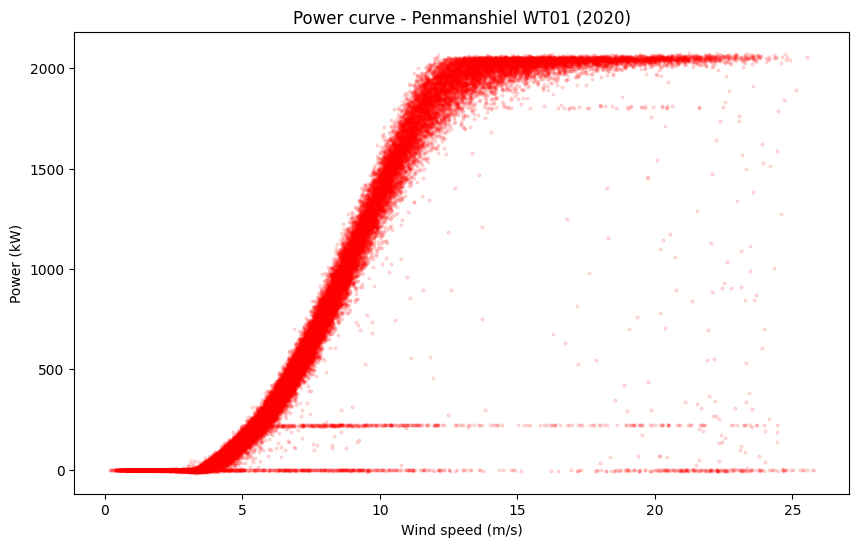

In [16]:
fig, ax =plt.subplots(figsize=(10,6))

ax.scatter(
    df_power_curve["Wind speed (m/s)"],
    df_power_curve["Power (kW)"],
    s=4,
    alpha=0.12,
    color="red",
)

ax.set_xlabel("Wind speed (m/s)")
ax.set_ylabel("Power (kW)")
ax.set_title("Power curve - Penmanshiel WT01 (2020)")

plt.show()

## Interpreting the power curve

The plot shows the expected S-shaped power curve: no output below the cut-in
speed (~3.5 m/s), a steep rise as wind speed increases, and a flat plateau at
the rated power (~2050 kW) from about 12-13 m/s onward. This matches the
physical behavior expected from a Senvion MM82 turbine.

Three groups of points fall outside this expected shape and are worth
investigating further:

1. **Zero power despite high wind speed** (a flat line near 0 kW extending up
   to 20-25 m/s). This suggests the turbine was stopped (maintenance, fault)
   while wind was available, not a sensor issue with the wind measurement itself.
2. **A fixed output around 220-250 kW across a wide range of wind speeds.**
   This pattern is consistent with curtailment, the turbine being deliberately
   limited by the grid operator, rather than a mechanical problem.
3. **Scattered points between 500 and 2000 kW at high wind speeds (15-25 m/s).**
   Output is less predictable in this range, possibly due to gusty conditions
   or control response variability.

These are hypotheses based on the shape of the data alone. The next step is to
cross-check these periods against the `Status` file to confirm the actual cause
(downtime, curtailment, or genuine anomaly) before drawing conclusions.


In [20]:
status=pd.read_csv("../data/raw/Status_Penmanshiel_01_2020-01-01_-_2021-01-01_1042.csv",skiprows=9)
print(status.shape)
status.head()

(10274, 9)


,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category
0,2020-01-01 00:04:22,2020-01-01 00:05:09,00:00:47,Informational,10,Wind < start wind,NaN,External stop (low wind speed) (5),Out of Environmental Specification
1,2020-01-01 00:04:22,-,-,Informational,100070,Brake program 50,NaN,NaN,Out of Environmental Specification
2,2020-01-01 00:05:09,-,-,Informational,0,System OK,NaN,System OK (32),Full Performance
3,2020-01-01 00:05:09,-,-,Informational,100130,Automatic start-up,NaN,NaN,Full Performance
4,2020-01-01 02:13:18,-,-,Informational,100180,Run-up,NaN,NaN,Technical Standby


In [21]:
status["Status"].value_counts()

Status
Informational    9907
Stop              254
Warning            87
Communication      26
Name: count, dtype: int64

In [22]:
status["IEC category"].value_counts()

IEC category
Full Performance                      6308
Out of Environmental Specification    2128
Technical Standby                     1646
Forced outage                           58
Scheduled Maintenance                   26
Partial Performance                      4
Requested Shutdown                       3
Name: count, dtype: int64

In [23]:
status[status["IEC category"]=="Scheduled Maintenance"]

,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category
1591,2020-03-02 12:32:23,2020-03-02 13:49:57,01:17:34,Stop,20,Manual stop - on site,NaN,Manual stop (service) (9),Scheduled Maintenance
2119,2020-03-31 12:54:17,2020-03-31 13:03:10,00:08:53,Stop,20,Manual stop - on site,NaN,Manual stop (service) (9),Scheduled Maintenance
2269,2020-04-09 11:49:57,2020-04-09 13:13:48,01:23:51,Stop,20,Manual stop - on site,NaN,Manual stop (service) (9),Scheduled Maintenance
2454,2020-04-13 14:28:56,2020-04-13 14:35:23,00:06:27,Stop,20,Manual stop - on site,NaN,Manual stop (service) (9),Scheduled Maintenance
2573,2020-04-17 07:51:54,2020-04-17 09:20:28,01:28:34,Stop,20,Manual stop - on site,NaN,Manual stop (service) (9),Scheduled Maintenance
4475,2020-06-12 10:04:13,2020-06-12 10:14:13,00:10:00,Stop,20,Manual stop - on site,NaN,Manual stop (service) (9),Scheduled Maintenance
4501,2020-06-12 10:16:04,2020-06-12 10:20:27,00:04:23,Stop,20,Manual stop - on site,NaN,Manual stop (service) (9),Scheduled Maintenance
5196,2020-07-03 11:09:02,2020-07-03 12:00:49,00:51:47,Stop,20,Manual stop - on site,NaN,Manual stop (service) (9),Scheduled Maintenance
5209,2020-07-03 12:03:10,2020-07-03 12:07:17,00:04:07,Stop,20,Manual stop - on site,NaN,Manual stop (service) (9),Scheduled Maintenance
7301,2020-08-17 11:57:21,2020-08-17 12:41:18,00:43:57,Stop,25,Manual stop without login,NaN,Manual stop (service) (9),Scheduled Maintenance


In [25]:
status[status["IEC category"]=="Partial Performance"]

,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category
6153,2020-07-31 15:46:31,2020-07-31 16:16:20,00:29:49,Warning,9000,P output externally reduced,NaN,Warnings (27),Partial Performance
6160,2020-07-31 16:21:52,2020-07-31 16:23:20,00:01:28,Warning,9000,P output externally reduced,NaN,Warnings (27),Partial Performance
7576,2020-08-25 14:44:19,2020-08-26 15:50:39,25:06:20,Warning,9000,P output externally reduced,NaN,Warnings (27),Partial Performance
9861,2020-12-07 14:37:45,2020-12-07 14:38:12,00:00:27,Warning,9000,P output externally reduced,NaN,Warnings (27),Partial Performance


In [32]:
status["Timestamp start"] = pd.to_datetime(status["Timestamp start"])


In [ ]:
# Look to the sep-oct gap

mask=(status["Timestamp start"] >= "2020-09-25") & (status["Timestamp start"] <= "2020-10-10")
status[mask]


,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category
8386,2020-09-25 07:25:52,2020-10-10 15:37:11,368:11:19,Stop,8000,Park master stop,NaN,Remote stop (30),Requested Shutdown
8387,2020-09-25 07:25:52,-,-,Informational,100060,Brake program 52,NaN,NaN,Full Performance
8388,2020-09-25 07:38:13,-,-,Informational,100035,Brake program 170,NaN,NaN,Full Performance
8389,2020-09-25 07:40:39,2020-10-10 15:11:29,367:30:50,Communication,9997,Data communication unavailable,NaN,NaN,NaN


## Cross-checking anomalies against the Status log

We checked two of the anomalies found in the power curve against the `Status`
event log, our only source of ground truth since the data has no anomaly labels.

**Plateau around 220-250 kW.** Confirmed as curtailment: `Status` shows
`Partial Performance` events with the message "P output externally reduced".
The output was deliberately limited from outside, not a fault.

**Missing data gap, 2020-09-25 to 2020-10-10 (~15 days).** Our first guess was
scheduled maintenance, but no such event matches this window, so we ruled it
out. Filtering by date instead showed a `Requested Shutdown` ("Park master
stop") together with a loss of SCADA communication, both lasting almost the
full 15 days. So the gap reflects a real remote stop, not a data error, even
though the exact reason isn't stated in the log.

**Scattered points at high wind speed (15-25 m/s, 500-2000 kW):** not checked
yet, left as an open question.

Most of what looked like "dirty data" turned out to be real, documented
turbine events once verified against an independent source, rather than
assumptions based on the plot alone.


In [45]:
suspicious=df_power_curve[(
    (df_power_curve["Wind speed (m/s)"] >=15) &
    (df_power_curve["Power (kW)"] < 1500))
]
print(suspicious.shape)
suspicious.head()


(356, 14)


,Date and time,Wind speed (m/s),"Wind speed, Standard deviation (m/s)",Power (kW),"Power, Standard deviation (kW)",Front bearing temperature (°C),Rear bearing temperature (°C),Nacelle temperature (°C),Generator bearing rear temperature (°C),Generator bearing front temperature (°C),Gear oil temperature (°C),Blade angle (pitch position) A (°),Blade angle (pitch position) B (°),Blade angle (pitch position) C (°)
202,2020-01-02 09:40:00,18.362963,3.679943,64.585916,372.082128,64.846667,56.818333,13.998333,44.253334,37.731667,53.041667,86.731477,86.732126,86.738891
203,2020-01-02 09:50:00,17.973809,3.405259,223.187915,609.961556,59.020000,53.013334,14.191667,43.935000,37.716666,50.666667,71.941813,71.937417,71.930666
931,2020-01-07 11:10:00,17.171112,4.169549,-4.109017,0.461880,64.111667,55.783333,14.866667,45.531666,38.960000,52.510000,89.990665,89.989998,89.989998
932,2020-01-07 11:20:00,21.077525,3.473766,-4.183351,0.807355,58.211667,52.573333,15.041667,44.895000,38.891668,50.980000,89.319609,89.321062,89.246926
933,2020-01-07 11:30:00,23.342343,4.708180,6.783589,45.937928,54.610000,51.170000,15.231667,43.558333,38.253333,50.453333,81.313026,81.311717,81.315817


In [46]:
suspicious["Date and time"].dt.date.value_counts().sort_index()

Date and time
2020-01-02     2
2020-01-07    37
2020-01-10     3
2020-01-11    78
2020-01-13     3
2020-01-30     7
2020-02-08    27
2020-02-09    15
2020-02-11    12
2020-02-12     1
2020-02-15    14
2020-02-16     8
2020-02-17    16
2020-02-22    22
2020-03-07     2
2020-05-22    21
2020-05-23     4
2020-08-21     2
2020-11-18     5
2020-12-03    14
2020-12-04    63
Name: count, dtype: int64

In [51]:
status_jan11=status[status["Timestamp start"].dt.date == pd.to_datetime("2020-01-11").date()]
status_jan11.head()

,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category
275,2020-01-11 00:03:45,-,-,Informational,0,System OK,NaN,System OK (32),Full Performance
276,2020-01-11 00:03:45,-,-,Informational,100130,Automatic start-up,NaN,NaN,Full Performance
277,2020-01-11 00:06:02,-,-,Informational,100180,Run-up,NaN,NaN,Technical Standby
278,2020-01-11 00:07:16,2020-01-11 00:17:46,00:10:30,Stop,64,Max. wind speed,NaN,External stop (low wind speed) (5),Out of Environmental Specification
279,2020-01-11 00:07:16,-,-,Informational,100060,Brake program 52,NaN,NaN,Full Performance


In [59]:
stops = status[status["Status"] == "Stop"]
stops["Message"].value_counts()


Message
Max. wind speed                     97
Battery test                        46
Manual stop - on site               22
Cable autounwind                    21
Frequency converter not ready       19
Tower oscillation Y level 1          9
Hydraulic oil flushing operation     8
Manual stop - remote                 7
Externally stopped                   5
Tower oscillation Y level 2          4
Manual stop without login            3
Repeating error BP52                 3
Park master stop                     3
Tower oscillation X level 2          2
Missing gear oil (high rpm)          2
Stop battery test                    1
Manual brake                         1
Safety chain open                    1
Name: count, dtype: int64

**Scattered points at high wind speed (15-25 m/s, 500-2000 kW).**
Confirmed as wind-related cut-outs. Across the sample days checked, the turbine
enters brief stop/restart cycles when wind exceeds its safe operating limit
("Max. wind speed"). This is the single most common stop reason in the whole
year (97 of 254 stops, ~38%), confirming that the dispersion at high wind
speed reflects normal protective behavior, not sensor error or a fault.


In [60]:
(df_key["Gear oil temperature (°C)"] < -275).sum()
(df_key["Gear oil temperature (°C)"] > 200).sum()

np.int64(0)

In [61]:
df_key["Gear oil temperature (°C)"].diff().eq(0).sum()

np.int64(22)

In [62]:
# Generator bearing front/rear, Front/Rear bearing, Nacelle temperature -> mismos límites (-275, 200)
print((df_key["Generator bearing front temperature (°C)"] < -275).sum())
print((df_key["Generator bearing front temperature (°C)"] > 200).sum())
print(df_key["Generator bearing front temperature (°C)"].diff().eq(0).sum())

0
0
155


In [63]:
print((df_key["Blade angle (pitch position) A (°)"] < -5).sum())
print((df_key["Blade angle (pitch position) A (°)"] > 360).sum())
print(df_key["Blade angle (pitch position) A (°)"].diff().eq(0).sum())


0
0
12336


In [64]:
flat_pitch = df_key["Blade angle (pitch position) A (°)"].diff().eq(0)
df_key[flat_pitch]["Power (kW)"].describe()

count    12336.000000
mean       342.487199
std        321.468955
min        -14.924585
25%         -1.444396
50%        368.519671
75%        584.406077
max       1372.253658
Name: Power (kW), dtype: float64

In [65]:
# Generator bearing rear temperature
print((df_key["Generator bearing rear temperature (°C)"] < -275).sum())
print((df_key["Generator bearing rear temperature (°C)"] > 200).sum())
print(df_key["Generator bearing rear temperature (°C)"].diff().eq(0).sum())

# Front bearing temperature
print((df_key["Front bearing temperature (°C)"] < -275).sum())
print((df_key["Front bearing temperature (°C)"] > 200).sum())
print(df_key["Front bearing temperature (°C)"].diff().eq(0).sum())

# Rear bearing temperature
print((df_key["Rear bearing temperature (°C)"] < -275).sum())
print((df_key["Rear bearing temperature (°C)"] > 200).sum())
print(df_key["Rear bearing temperature (°C)"].diff().eq(0).sum())

# Nacelle temperature
print((df_key["Nacelle temperature (°C)"] < -275).sum())
print((df_key["Nacelle temperature (°C)"] > 200).sum())
print(df_key["Nacelle temperature (°C)"].diff().eq(0).sum())

# Blade angle (pitch position) B
print((df_key["Blade angle (pitch position) B (°)"] < -5).sum())
print((df_key["Blade angle (pitch position) B (°)"] > 360).sum())
print(df_key["Blade angle (pitch position) B (°)"].diff().eq(0).sum())

# Blade angle (pitch position) C
print((df_key["Blade angle (pitch position) C (°)"] < -5).sum())
print((df_key["Blade angle (pitch position) C (°)"] > 360).sum())
print(df_key["Blade angle (pitch position) C (°)"].diff().eq(0).sum())


0
0
196
0
0
140
0
0
112
0
0
180
0
0
12459
1
0
12415


In [66]:
df_key[df_key["Blade angle (pitch position) C (°)"] < -5]

,Date and time,Wind speed (m/s),"Wind speed, Standard deviation (m/s)",Power (kW),"Power, Standard deviation (kW)",Front bearing temperature (°C),Rear bearing temperature (°C),Nacelle temperature (°C),Generator bearing rear temperature (°C),Generator bearing front temperature (°C),Gear oil temperature (°C),Blade angle (pitch position) A (°),Blade angle (pitch position) B (°),Blade angle (pitch position) C (°)
48598,2020-12-03 11:40:00,2.645685,0.210228,-3.794963,0.810397,37.241666,39.266667,10.476,25.44,30.502,41.746001,41.022498,92.489998,-19.662499


## Data quality check: temperatures and pitch

We checked all temperature and pitch columns against the dictionary's physical
limits, and for "frozen" values (identical consecutive readings), which could
indicate a stuck sensor.

**Temperatures** (gearbox, generator bearings, main bearings, nacelle): no
out-of-range values, and repeated consecutive readings are negligible
(0.2-0.4% of the year). Clean data.

**Pitch (blades A, B, C):** about 23% of readings stay flat compared to the
previous one, much higher than the temperatures. Checking Power during those
flat periods showed a wide range, including moderate output, not just zero.
This is consistent with normal turbine control: pitch is held near a fixed
angle below rated power, and only actively adjusted near or above rated power
to limit output. Not a sensor issue.

Minor: one reading in Blade angle C is -20°, outside the physical range
(-5 to 360). A single isolated value, likely a sensor glitch; negligible
given the sample size.


In [67]:
(df_key["Power (kW)"] < 0).sum()

np.int64(7002)

In [68]:
df_key[df_key["Power (kW)"] < 0]["Power (kW)"].describe()

count    7002.000000
mean       -2.104878
std         1.429474
min       -14.924585
25%        -2.263063
50%        -1.651894
75%        -1.392297
max        -0.022178
Name: Power (kW), dtype: float64

In [69]:
print(df_key["Date and time"].duplicated().sum())
print(df_key["Date and time"].diff().value_counts().head())

0
Date and time
0 days 00:10:00    52703
Name: count, dtype: int64


## Summary of findings

- The power curve matches the expected shape for this turbine model, with
  three deviations fully explained via the `Status` log: external curtailment
  (~220-250 kW plateau), a ~15-day remote shutdown with lost communication
  (2020-09-25 to 2020-10-10), and wind-speed cut-out/restart cycles at high
  wind (the most common stop reason overall, 97 of 254 stops).
- Temperature and pitch signals are clean: no out-of-range values (one
  isolated glitch in Blade angle C), and no evidence of frozen sensors.
- Negative Power readings (13% of rows) are small in magnitude (max -14.9 kW),
  consistent with normal auxiliary power consumption, not a data error.
- The 10-minute timestamp grid has no gaps or duplicates; missing sensor
  values during downtime don't create missing rows.

Overall, this year of WT01 data is high quality once cross-checked against
the Status log. Most "dirty-looking" points in the raw power curve are real,
explainable turbine events rather than data errors.
